# Lab 2 — Perceptron, Linear Separability, and XOR

**Course:** Mathematical Foundations of Machine and Deep Learning (beginner+)  
**Lab duration:** ~1.5h (10 min intro + 70 min hands-on + 10 min wrap-up)

**Content (what we’ll do):**  
This lab introduces the perceptron as a linear classifier and uses logical operators to build intuition about linear separability.
You will see that AND/OR are solvable with a linear decision boundary, while XOR is not.
You will implement a perceptron from scratch, compare it with scikit-learn, visualize decision boundaries,
and then “fix” XOR using a simple feature map (and optionally a tiny neural network), highlighting the importance of representation.


## Learning objectives (you should be able to…)
1. Explain what **linear separability** means geometrically in 2D (a line splitting classes).
2. Describe the **perceptron update rule** and why it is a “mistake-driven” algorithm.
3. Train and evaluate a perceptron on AND/OR and diagnose failure on XOR.
4. Visualize **decision boundaries** using a meshgrid and interpret what you see.
5. “Fix” XOR by changing representation (feature map) and compare with a non-linear model.

## Minute-by-minute plan (90 minutes total)
**Intro (10 min)**
- Linear separability + hyperplane intuition (2D line)
- Perceptron update rule intuition
- Preview: XOR failure + how feature maps / non-linear models help

**Hands-on (70 min)**
- Module 1 (15 min): build AND/OR/XOR datasets + visualize
- Module 2 (20 min): perceptron from scratch + boundaries + error curves
- Module 3 (10 min): sklearn Perceptron comparison
- Module 4 (20 min): “fix XOR” via feature map (required) + tiny MLP (optional)
- Module 5 (5 min): quick non-linear baseline (RBF SVM or small tree)

**Wrap-up (10 min)**
- Key takeaways + checklist + concept questions


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Optional styling (keep minimal; seaborn is optional)
try:
    import seaborn as sns
    sns.set_context("notebook")
except Exception:
    pass

from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
# Alternative baseline if you prefer:
# from sklearn.tree import DecisionTreeClassifier

np.set_printoptions(precision=3, suppress=True)

def plot_scatter(X, y, ax=None, title="", xlabel="x1", ylabel="x2"):
    """
    Scatter plot for 2D binary classification.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    X = np.asarray(X)
    y = np.asarray(y)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], label="class 0", alpha=0.9)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], label="class 1", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax

def plot_decision_boundary(model, X, y, ax=None, title="", padding=0.5, h=0.02):
    """
    Plot decision boundary for a classifier with predict(X) method.
    Works for 2D input features.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    X = np.asarray(X)
    y = np.asarray(y)

    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    plot_scatter(X, y, ax=ax, title=title)
    return ax

def plot_errors(errors, ax=None, title="Misclassifications per epoch"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(np.arange(1, len(errors) + 1), errors, marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("# misclassifications")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


### Instructor notes (short theory)

**Linear separability (2D):**  
A dataset is *linearly separable* if you can draw a straight line that puts all class-0 points on one side and all class-1 points on the other. In higher dimensions, that “line” becomes a **hyperplane**.

**Perceptron intuition:**  
The perceptron predicts using a weighted sum: `w · x + b`. If it makes a mistake on a point, it nudges the weights in the direction that would correct that mistake. This is why it’s often called **mistake-driven learning**.

**Preview: XOR failure:**  
XOR cannot be separated by a single line in 2D—no matter how you rotate it. To solve XOR, we can:
- change the representation (feature map), or  
- use a non-linear model (e.g., a small neural network or RBF SVM).


## MODULE 1 — Build the datasets (AND / OR / XOR) and visualize

We start with the four binary input points in 2D: (0,0), (0,1), (1,0), (1,1).  
Then we create labels for AND / OR / XOR and optionally add small noise (jitter or bit flips).  
Finally, we visualize each dataset to build geometric intuition.

**What do you observe?**  
AND/OR should “look” separable by a line. XOR should look like a checkerboard pattern.

**Expected takeaway:**  
Geometry (how points sit in space) matters as much as the rule that generated the labels.


In [11]:
# Base inputs: all 4 combinations
X_base = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

X_base


array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

### Task 1.1 — Implement label functions

We will implement three label functions that map a 2D binary input `x = (x1, x2)` to {0,1}.  
Use integer logic: AND is 1 only if both are 1, OR is 1 if at least one is 1, XOR is 1 if exactly one is 1.

**What do you observe?**  
XOR assigns the “diagonal” corners to different classes than the other diagonal — that’s the source of non-separability.

**Expected takeaway:**  
Logical rules can produce very different geometries even on the same input space.


In [12]:
def label_and(X):
    """
    X: (n,2) array with values in {0,1} (or close to it)
    returns y in {0,1}
    """
    # TODO: implement AND labels for rows of X
    # --- SOLUTION (instructor) ---
    # return ((X[:, 0] == 1) & (X[:, 1] == 1)).astype(int)

    return ((X[:, 0] >= 0.5) & (X[:, 1] >= 0.5)).astype(int)  # fallback so the notebook runs


def label_or(X):
    # TODO: implement OR labels for rows of X
    # --- SOLUTION (instructor) ---
    # return ((X[:, 0] == 1) | (X[:, 1] == 1)).astype(int)

    return ((X[:, 0] >= 0.5) | (X[:, 1] >= 0.5)).astype(int)  # fallback so the notebook runs


def label_xor(X):
    # TODO: implement XOR labels for rows of X
    # --- SOLUTION (instructor) ---
    # return ((X[:, 0] == 1) ^ (X[:, 1] == 1)).astype(int)

    # fallback so the notebook runs
    x1 = (X[:, 0] >= 0.5).astype(int)
    x2 = (X[:, 1] >= 0.5).astype(int)
    return (x1 != x2).astype(int)

y_and = label_and(X_base)
y_or  = label_or(X_base)
y_xor = label_xor(X_base)

y_and, y_or, y_xor


(array([0, 0, 0, 1]), array([0, 1, 1, 1]), array([0, 1, 1, 0]))

### Task 1.2 — Add noise to create a small dataset

To make training and boundaries more interesting, we will replicate the 4 points many times and add noise:
- **jitter:** add small Gaussian noise to coordinates (continuous scatter)
- **bit flip (optional):** randomly flip 0↔1 with small probability (discrete corruption)

**What do you observe?**  
With too much noise, even AND/OR may become harder to separate perfectly.

**Expected takeaway:**  
Noise can break perfect structure, but linearly separable problems often remain “mostly separable” under small noise.


In [13]:
def make_noisy_dataset(X_base, y_base, n_repeats=50, jitter=0.15, flip_prob=0.0, random_state=0):
    rng = np.random.default_rng(random_state)

    # Repeat points
    X = np.repeat(X_base, n_repeats, axis=0).copy()
    y = np.repeat(y_base, n_repeats, axis=0).copy()

    # TODO: add jitter (Gaussian noise) to X
    # --- SOLUTION (instructor) ---
    # X += rng.normal(loc=0.0, scale=jitter, size=X.shape)

    X += rng.normal(loc=0.0, scale=jitter, size=X.shape)  # fallback so the notebook runs

    # Optional: bit flips (flip 0<->1 with probability flip_prob)
    # TODO: implement bit flips
    # --- SOLUTION (instructor) ---
    # if flip_prob > 0:
    #     flips = rng.random(X.shape) < flip_prob
    #     X[flips] = 1 - np.round(X[flips])

    if flip_prob > 0:
        flips = rng.random(X.shape) < flip_prob  # fallback so the notebook runs
        X[flips] = 1 - np.round(X[flips])

    return X, y

# Build three datasets
X_and, y_and_big = make_noisy_dataset(X_base, y_and, n_repeats=60, jitter=0.12, flip_prob=0.0, random_state=1)
X_or,  y_or_big  = make_noisy_dataset(X_base, y_or,  n_repeats=60, jitter=0.12, flip_prob=0.0, random_state=2)
X_xor, y_xor_big = make_noisy_dataset(X_base, y_xor, n_repeats=60, jitter=0.12, flip_prob=0.0, random_state=3)

X_and.shape, X_or.shape, X_xor.shape


((240, 2), (240, 2), (240, 2))

### Task 1.3 — Plot scatter for AND / OR / XOR

A quick scatter plot already hints at which datasets can be separated by a line.  
We plot the three datasets side-by-side using the helper `plot_scatter`.

**What do you observe?**  
XOR forms a “checkerboard” pattern: diagonally opposite corners share the same label.

**Expected takeaway:**  
Before modeling, always visualize—many model failures are visible in the geometry.


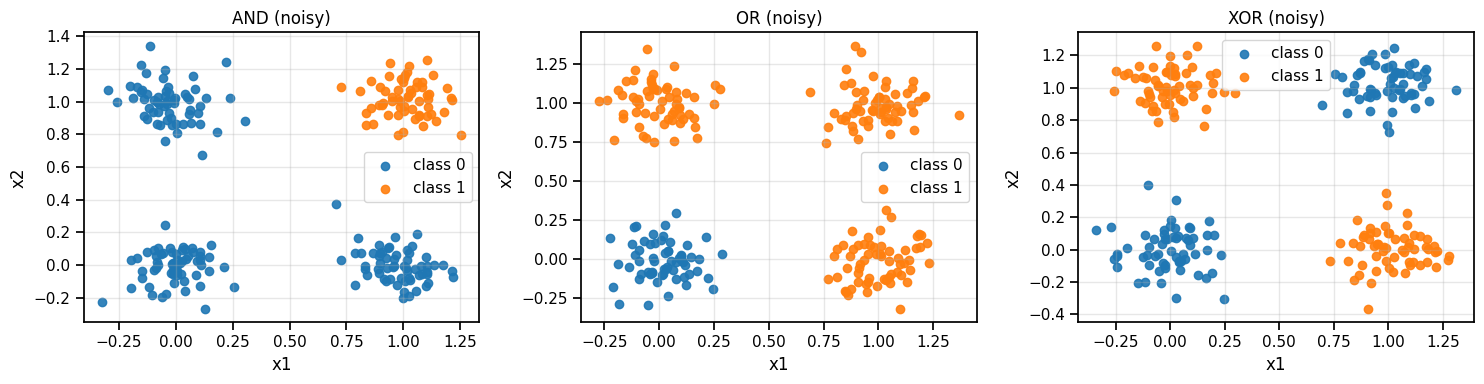

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TODO: call plot_scatter for AND/OR/XOR
# --- SOLUTION (instructor) ---
# plot_scatter(X_and, y_and_big, ax=axes[0], title="AND (noisy)")
# plot_scatter(X_or,  y_or_big,  ax=axes[1], title="OR (noisy)")
# plot_scatter(X_xor, y_xor_big, ax=axes[2], title="XOR (noisy)")

plot_scatter(X_and, y_and_big, ax=axes[0], title="AND (noisy)")  # fallback so the notebook runs
plot_scatter(X_or,  y_or_big,  ax=axes[1], title="OR (noisy)")
plot_scatter(X_xor, y_xor_big, ax=axes[2], title="XOR (noisy)")

plt.tight_layout()
plt.show()


## MODULE 2 — Train a perceptron from scratch

We will implement a minimal perceptron:
- weights `w` and bias `b` (we’ll store bias inside `w_[0]`)
- update rule for each misclassified example
- `errors_`: number of misclassifications per epoch

**What do you observe?**  
On linearly separable data, the perceptron often reaches zero training errors (with enough epochs).  
On XOR, it should not converge to zero.

**Expected takeaway:**  
Perceptron works when a linear separator exists; otherwise it keeps oscillating (errors don’t vanish).


In [15]:
class PerceptronScratch:
    def __init__(self, lr=0.1, epochs=20, random_state=0):
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state
        self.w_ = None
        self.errors_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y)

        # Initialize weights: w_[0] is bias, w_[1:] are feature weights
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                # TODO: compute update using perceptron rule and apply it to weights
                # --- SOLUTION (instructor) ---
                # pred = self.predict(xi.reshape(1, -1))[0]
                # update = self.lr * (target - pred)
                # self.w_[1:] += update * xi
                # self.w_[0]  += update
                # errors += int(update != 0.0)

                # fallback so the notebook runs (using correct rule)
                pred = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (target - pred)
                self.w_[1:] += update * xi
                self.w_[0]  += update
                errors += int(update != 0.0)

            # TODO: store errors per epoch in self.errors_
            # --- SOLUTION (instructor) ---
            # self.errors_.append(errors)

            self.errors_.append(errors)  # fallback so the notebook runs

        return self

    def net_input(self, X):
        X = np.asarray(X)
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # TODO: implement prediction threshold (>=0 -> class 1 else 0)
        # --- SOLUTION (instructor) ---
        # return (self.net_input(X) >= 0.0).astype(int)

        return (self.net_input(X) >= 0.0).astype(int)  # fallback so the notebook runs


### Task 2.1 — Train perceptron on AND

We fit the scratch perceptron and inspect:
- `errors_` curve: should decrease and often reach 0
- decision boundary: should be a line splitting the classes

**What do you observe?**  
Does the error curve hit zero? Does the boundary look reasonable?

**Expected takeaway:**  
For AND, a single line can separate the positive class (near (1,1)) from the others.


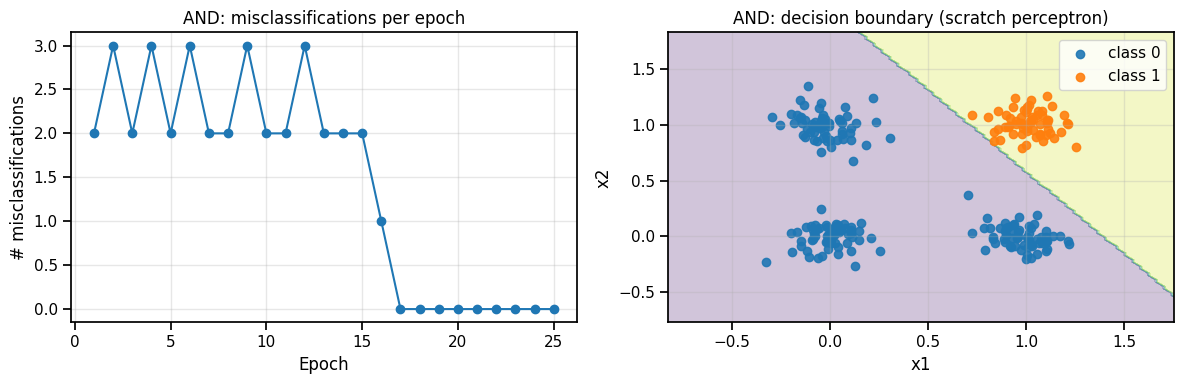

AND training accuracy: 1.0


In [16]:
ppn_and = PerceptronScratch(lr=0.1, epochs=25, random_state=0)

# TODO: fit on (X_and, y_and_big)
# --- SOLUTION (instructor) ---
# ppn_and.fit(X_and, y_and_big)

ppn_and.fit(X_and, y_and_big)  # fallback so the notebook runs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_errors(ppn_and.errors_, ax=axes[0], title="AND: misclassifications per epoch")
plot_decision_boundary(ppn_and, X_and, y_and_big, ax=axes[1], title="AND: decision boundary (scratch perceptron)")
plt.tight_layout()
plt.show()

# Quick training accuracy
y_pred_and = ppn_and.predict(X_and)
print("AND training accuracy:", accuracy_score(y_and_big, y_pred_and))


### Task 2.2 — Train perceptron on OR

OR is also linearly separable. The positive class is “everything except (0,0)” (with noise).  
Again inspect error curve and boundary.

**What do you observe?**  
Is it easier/harder than AND under jitter?

**Expected takeaway:**  
Different linearly separable rules can still vary in difficulty depending on noise and class geometry.


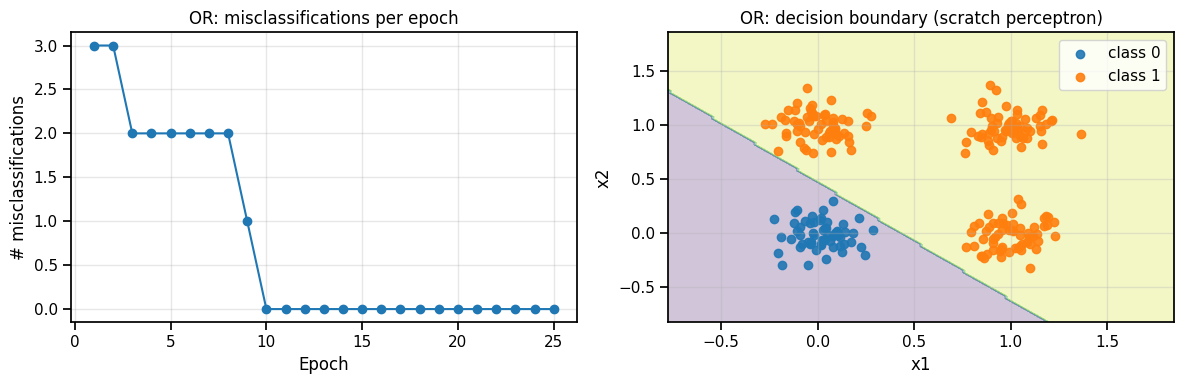

OR training accuracy: 1.0


In [17]:
ppn_or = PerceptronScratch(lr=0.1, epochs=25, random_state=1)

# TODO: fit on (X_or, y_or_big)
# --- SOLUTION (instructor) ---
# ppn_or.fit(X_or, y_or_big)

ppn_or.fit(X_or, y_or_big)  # fallback so the notebook runs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_errors(ppn_or.errors_, ax=axes[0], title="OR: misclassifications per epoch")
plot_decision_boundary(ppn_or, X_or, y_or_big, ax=axes[1], title="OR: decision boundary (scratch perceptron)")
plt.tight_layout()
plt.show()

y_pred_or = ppn_or.predict(X_or)
print("OR training accuracy:", accuracy_score(y_or_big, y_pred_or))


### Task 2.3 — Train perceptron on XOR (expect failure)

Now we try XOR with the same linear perceptron.  
Because XOR is not linearly separable in 2D, the perceptron cannot find a separating line that classifies all points correctly.

**What do you observe?**  
The errors curve should not go to 0, and the boundary will misclassify parts of the space.

**Expected takeaway:**  
A linear model can fail *systematically*—not due to “bad training” but due to geometry.


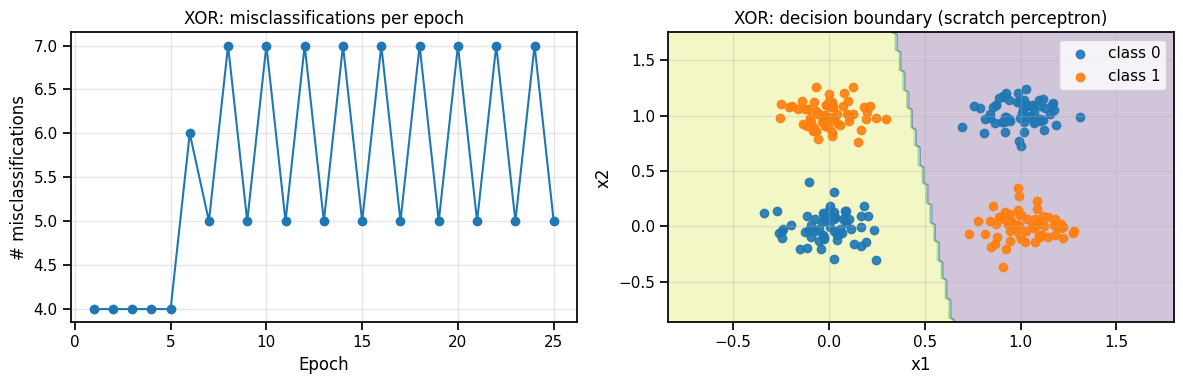

XOR training accuracy (scratch perceptron): 0.5


In [18]:
ppn_xor = PerceptronScratch(lr=0.1, epochs=25, random_state=2)

# TODO: fit on (X_xor, y_xor_big)
# --- SOLUTION (instructor) ---
# ppn_xor.fit(X_xor, y_xor_big)

ppn_xor.fit(X_xor, y_xor_big)  # fallback so the notebook runs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_errors(ppn_xor.errors_, ax=axes[0], title="XOR: misclassifications per epoch")
plot_decision_boundary(ppn_xor, X_xor, y_xor_big, ax=axes[1], title="XOR: decision boundary (scratch perceptron)")
plt.tight_layout()
plt.show()

y_pred_xor = ppn_xor.predict(X_xor)
print("XOR training accuracy (scratch perceptron):", accuracy_score(y_xor_big, y_pred_xor))


### Reflection — Why does XOR fail?

Try to draw a single straight line that separates the two XOR classes:
- class 1: points near (0,1) and (1,0)
- class 0: points near (0,0) and (1,1)

No single line can separate these diagonally opposed clusters.

**What do you observe?**  
Any line that puts (0,1) and (1,0) on one side will also capture either (0,0) or (1,1).

**Expected takeaway:**  
XOR requires either a non-linear boundary in 2D or a representation change that makes it separable in a higher dimension.


## MODULE 3 — Compare with sklearn Perceptron

scikit-learn implements an optimized perceptron with options like shuffling and regularization-like effects.  
We will train it on AND/OR/XOR and compare accuracies.  
We also visualize the decision boundary on XOR (it should still fail because the model is linear).

**What do you observe?**  
Accuracy on AND/OR should be high; XOR should be limited.

**Expected takeaway:**  
A better implementation doesn’t overcome a representational limitation (linearity).


sklearn Perceptron accuracy — AND: 1.000, OR: 1.000, XOR: 0.637


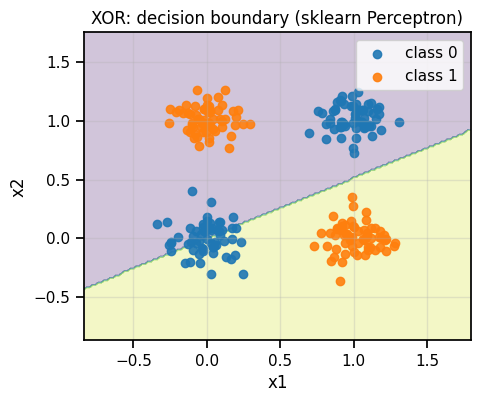

In [19]:
def train_eval_sklearn_perceptron(X, y, random_state=0):
    model = SkPerceptron(max_iter=1000, tol=1e-3, random_state=random_state)

    # TODO: fit model on (X, y)
    # --- SOLUTION (instructor) ---
    # model.fit(X, y)

    model.fit(X, y)  # fallback so the notebook runs

    # TODO: compute accuracy
    # --- SOLUTION (instructor) ---
    # y_pred = model.predict(X)
    # acc = accuracy_score(y, y_pred)

    y_pred = model.predict(X)  # fallback so the notebook runs
    acc = accuracy_score(y, y_pred)
    return model, acc

sk_and, acc_and = train_eval_sklearn_perceptron(X_and, y_and_big, random_state=0)
sk_or,  acc_or  = train_eval_sklearn_perceptron(X_or,  y_or_big,  random_state=1)
sk_xor, acc_xor = train_eval_sklearn_perceptron(X_xor, y_xor_big, random_state=2)

print(f"sklearn Perceptron accuracy — AND: {acc_and:.3f}, OR: {acc_or:.3f}, XOR: {acc_xor:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_decision_boundary(sk_xor, X_xor, y_xor_big, ax=ax, title="XOR: decision boundary (sklearn Perceptron)")
plt.show()


## MODULE 4 — “Fix XOR” (Approach A required): Feature map

A classic trick: map 2D inputs (x1, x2) into 3D features (x1, x2, z) where `z = x1 * x2`.  
In this new space, XOR can become linearly separable (a plane in 3D).  
We will train a linear classifier on the mapped features and evaluate.

**Visualization strategy:**  
Since our boundary now lives in 3D, we’ll verify correctness on:
- the four clean corner points, and  
- the noisy dataset accuracy.

**What do you observe?**  
Accuracy should improve substantially compared to linear perceptron on 2D XOR.

**Expected takeaway:**  
Representation (feature engineering) can turn an “impossible” linear problem into a solvable one.


In [20]:
def add_feature_z(X):
    """
    Feature map: (x1, x2) -> (x1, x2, z=x1*x2)
    """
    X = np.asarray(X)

    # TODO: construct z = x1*x2 and return augmented features
    # --- SOLUTION (instructor) ---
    # z = (X[:, 0] * X[:, 1]).reshape(-1, 1)
    # return np.hstack([X, z])

    z = (X[:, 0] * X[:, 1]).reshape(-1, 1)  # fallback so the notebook runs
    return np.hstack([X, z])

X_xor_phi = add_feature_z(X_xor)

# Train a linear model in the feature space (use sklearn Perceptron for simplicity)
phi_model = SkPerceptron(max_iter=2000, tol=1e-4, random_state=0)

# TODO: fit phi_model on mapped features and evaluate
# --- SOLUTION (instructor) ---
# phi_model.fit(X_xor_phi, y_xor_big)
# y_pred_phi = phi_model.predict(X_xor_phi)
# acc_phi = accuracy_score(y_xor_big, y_pred_phi)

phi_model.fit(X_xor_phi, y_xor_big)  # fallback so the notebook runs
y_pred_phi = phi_model.predict(X_xor_phi)
acc_phi = accuracy_score(y_xor_big, y_pred_phi)

print("XOR accuracy with feature map (x1,x2,x1*x2) + linear perceptron:", acc_phi)

# Verify on the 4 clean points
X_clean_phi = add_feature_z(X_base)
y_clean_pred = phi_model.predict(X_clean_phi)
print("Clean XOR inputs:\n", X_base)
print("True XOR labels: ", y_xor)
print("Pred XOR labels: ", y_clean_pred)


XOR accuracy with feature map (x1,x2,x1*x2) + linear perceptron: 1.0
Clean XOR inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
True XOR labels:  [0 1 1 0]
Pred XOR labels:  [0 1 1 0]


### Optional: 3D intuition (quick)

This is optional. If you’ve seen 3D plots before, this can help:  
we visualize points in (x1, x2, z) space. A plane (linear separator) can separate them.

**Expected takeaway:**  
A linear separator in higher dimension can correspond to a non-linear rule in the original space.


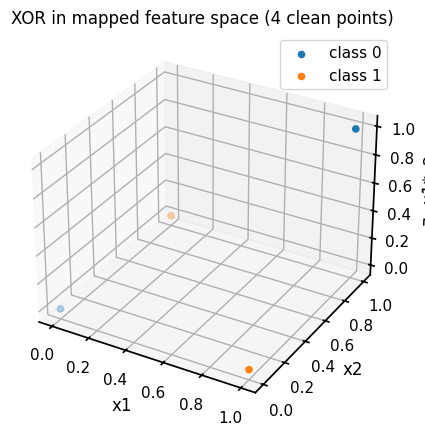

In [21]:
# Optional 3D scatter (lightweight)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X_phi_base = add_feature_z(X_base)
y_phi_base = y_xor

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_phi_base[y_phi_base==0, 0], X_phi_base[y_phi_base==0, 1], X_phi_base[y_phi_base==0, 2], label="class 0")
ax.scatter(X_phi_base[y_phi_base==1, 0], X_phi_base[y_phi_base==1, 1], X_phi_base[y_phi_base==1, 2], label="class 1")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("z=x1*x2")
ax.set_title("XOR in mapped feature space (4 clean points)")
ax.legend()
plt.show()


## MODULE 4 — Approach B (optional extension): Tiny neural network

A two-layer neural network (one hidden layer) can represent XOR with a non-linear decision boundary.  
We use `MLPClassifier(hidden_layer_sizes=(2,))` which is the smallest “interesting” hidden layer size for XOR.

**What do you observe?**  
The decision boundary should bend to separate the XOR classes.

**Expected takeaway:**  
Non-linear models can learn non-linearly separable patterns without manual feature engineering.


XOR accuracy (tiny MLP): 0.75


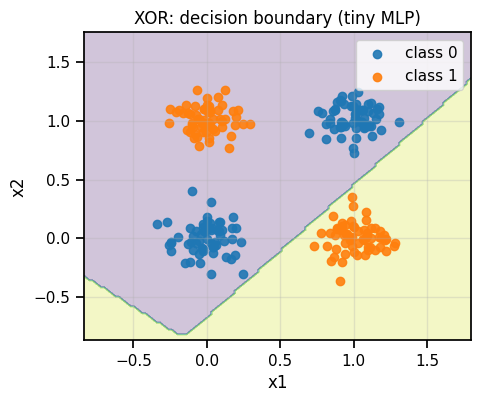

In [22]:
mlp = MLPClassifier(hidden_layer_sizes=(2,),
                    activation="tanh",
                    solver="lbfgs",
                    max_iter=2000,
                    random_state=0)

# TODO: fit MLP on XOR and evaluate accuracy
# --- SOLUTION (instructor) ---
# mlp.fit(X_xor, y_xor_big)
# y_pred_mlp = mlp.predict(X_xor)
# acc_mlp = accuracy_score(y_xor_big, y_pred_mlp)

mlp.fit(X_xor, y_xor_big)  # fallback so the notebook runs
y_pred_mlp = mlp.predict(X_xor)
acc_mlp = accuracy_score(y_xor_big, y_pred_mlp)
print("XOR accuracy (tiny MLP):", acc_mlp)

fig, ax = plt.subplots(figsize=(5, 4))
plot_decision_boundary(mlp, X_xor, y_xor_big, ax=ax, title="XOR: decision boundary (tiny MLP)")
plt.show()


## MODULE 5 — Quick non-linear baseline (contrast): SVM with RBF kernel

We add one more comparison model: **SVM with RBF kernel**, which can create flexible, curved boundaries.  
This is a strong baseline for small 2D problems like XOR.

**What do you observe?**  
The boundary is typically smooth and separates XOR well.

**Expected takeaway:**  
Non-linear kernels (or trees) can solve XOR directly in 2D by using non-linear decision boundaries.


XOR accuracy (SVM RBF): 1.0


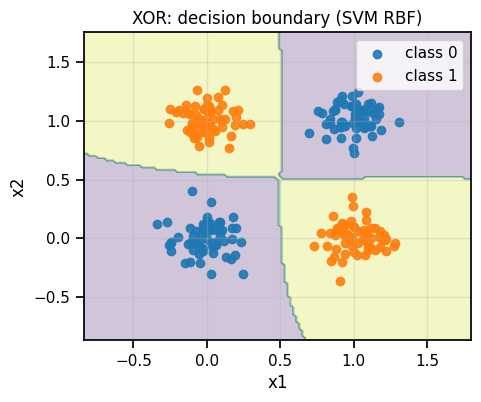

In [23]:
svm_rbf = SVC(kernel="rbf", gamma="scale", C=1.0)

# TODO: fit SVM on XOR, compute accuracy, plot boundary
# --- SOLUTION (instructor) ---
# svm_rbf.fit(X_xor, y_xor_big)
# y_pred_svm = svm_rbf.predict(X_xor)
# acc_svm = accuracy_score(y_xor_big, y_pred_svm)

svm_rbf.fit(X_xor, y_xor_big)  # fallback so the notebook runs
y_pred_svm = svm_rbf.predict(X_xor)
acc_svm = accuracy_score(y_xor_big, y_pred_svm)
print("XOR accuracy (SVM RBF):", acc_svm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_decision_boundary(svm_rbf, X_xor, y_xor_big, ax=ax, title="XOR: decision boundary (SVM RBF)")
plt.show()


# Wrap-up

## Key takeaways (6–8 bullets)
- The perceptron is a **linear classifier**: it draws a line (2D) / hyperplane (higher-D).
- **Linear separability** is a geometric property of the dataset, not of the training algorithm.
- AND and OR are linearly separable in 2D; XOR is **not**.
- The perceptron update rule is **mistake-driven**: update only when a point is misclassified.
- Visualizing a **decision boundary** often reveals why a model succeeds or fails.
- XOR can be “fixed” by changing representation (feature map) or using a **non-linear model**.
- Feature maps can turn non-linear patterns into linear ones in a higher-dimensional space.
- Non-linear models (MLP, RBF SVM) can learn curved boundaries directly in 2D.

## Checklist — when perceptron works / when it fails (≥10 bullets)
**Perceptron tends to work well when:**
- ✅ Data is (approximately) **linearly separable**
- ✅ Classes form two clusters separable by a line
- ✅ Noise is small enough that a clear margin exists
- ✅ You can accept a linear boundary for interpretability
- ✅ Features are scaled reasonably (avoid extreme ranges)
- ✅ You have a decent number of epochs (and/or shuffling)
- ✅ Labels are consistent (few contradictory points)
- ✅ You want a fast baseline model

**Perceptron tends to fail when:**
- ❌ Data is **not** linearly separable (e.g., XOR pattern)
- ❌ Classes are interleaved / checkerboard-like
- ❌ Strong label noise makes perfect separation impossible
- ❌ The true boundary is strongly non-linear
- ❌ You need calibrated probabilities (perceptron doesn’t provide them directly)
- ❌ Features don’t represent the structure (bad representation)
- ❌ You need robustness to outliers without careful preprocessing

## Concept questions (4–6)
1. **Geometry:** What does it mean (in 2D) that a dataset is linearly separable? How would you test it visually?
2. **Convergence (informal):** Under what condition does the perceptron typically converge to zero training errors? (Hint: separability + enough epochs.)
3. **XOR:** Explain in your own words why XOR cannot be separated by a single line in 2D.
4. **Feature maps:** How can adding a feature like `z = x1*x2` make a previously non-separable dataset separable?
5. **Non-linear models:** Why can an RBF SVM or a small MLP solve XOR without manual feature engineering?
6. **Visualization:** What specific insight do you gain from decision boundary plots that you might miss from accuracy alone?


### Optional self-check

Run this cell to quickly compare models on XOR and confirm the main message:
- linear perceptrons struggle
- feature map and non-linear models succeed


In [24]:
results = {
    "Scratch perceptron (2D)": accuracy_score(y_xor_big, ppn_xor.predict(X_xor)),
    "sklearn perceptron (2D)": acc_xor,
    "Feature map + linear": acc_phi,
    "Tiny MLP (2D)": acc_mlp,
    "SVM RBF (2D)": acc_svm,
}
for k, v in results.items():
    print(f"{k:25s} -> {v:.3f}")


Scratch perceptron (2D)   -> 0.500
sklearn perceptron (2D)   -> 0.637
Feature map + linear      -> 1.000
Tiny MLP (2D)             -> 0.750
SVM RBF (2D)              -> 1.000
